## 1. Setup & Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [15]:
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import lightgbm as lgb



## 2. Load & Explore Data

In [16]:
df = pd.read_csv("data\plant_health_data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (1200, 15)


,Timestamp,Plant_ID,Plant_Name,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,Spinach,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,Spinach,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,Spinach,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,Spinach,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,Spinach,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [4]:
print("=== Data Types & Non-null Counts ===")
df.info()


=== Data Types & Non-null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1200 non-null   str    
 1   Plant_ID                1200 non-null   int64  
 2   Plant_Name              1200 non-null   str    
 3   Soil_Moisture           1200 non-null   float64
 4   Ambient_Temperature     1200 non-null   float64
 5   Soil_Temperature        1200 non-null   float64
 6   Humidity                1200 non-null   float64
 7   Light_Intensity         1200 non-null   float64
 8   Soil_pH                 1200 non-null   float64
 9   Nitrogen_Level          1200 non-null   float64
 10  Phosphorus_Level        1200 non-null   float64
 11  Potassium_Level         1200 non-null   float64
 12  Chlorophyll_Content     1200 non-null   float64
 13  Electrochemical_Signal  1200 non-null   float64
 14  Plant_Health_S

In [5]:
print("=== Missing Values ===")
print(df.isna().sum())
print(f"\nTotal missing: {df.isna().sum().sum()}")


=== Missing Values ===
Timestamp                 0
Plant_ID                  0
Plant_Name                0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH                   0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Chlorophyll_Content       0
Electrochemical_Signal    0
Plant_Health_Status       0
dtype: int64

Total missing: 0


In [6]:
print("=== Descriptive Statistics ===")
df.describe().T.style.format("{:.2f}")


=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Plant_ID,1200.00,5.50,2.87,1.00,3.00,5.50,8.00,10.00
Soil_Moisture,1200.00,25.11,8.68,10.00,17.13,25.17,32.37,39.99
Ambient_Temperature,1200.00,24.00,3.44,18.00,21.10,23.89,27.04,29.99
Soil_Temperature,1200.00,19.96,2.93,15.00,17.35,19.91,22.60,25.00
Humidity,1200.00,54.85,8.78,40.03,47.02,54.69,62.45,69.97
Light_Intensity,1200.00,612.64,228.32,200.62,416.88,617.24,811.47,999.86
Soil_pH,1200.00,6.52,0.58,5.51,6.03,6.54,7.03,7.50
Nitrogen_Level,1200.00,30.11,11.51,10.00,20.25,30.14,40.18,49.95
Phosphorus_Level,1200.00,30.26,11.47,10.02,20.89,30.02,40.13,49.98
Potassium_Level,1200.00,30.11,11.67,10.00,19.59,30.50,40.11,49.98


=== Target Class Distribution ===


,Count,Percent (%)
Plant_Health_Status,,
High Stress,500,41.67
Moderate Stress,401,33.42
Healthy,299,24.92


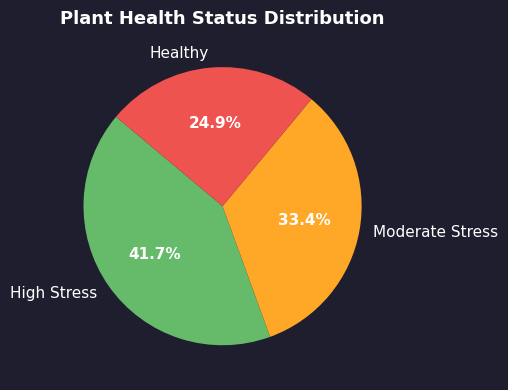

In [7]:
print("=== Target Class Distribution ===")
cnt = df['Plant_Health_Status'].value_counts()
pct = df['Plant_Health_Status'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': cnt, 'Percent (%)': pct.round(2)})
display(dist_df)

# Pie chart
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')
colors = ['#66BB6A', '#FFA726', '#EF5350']
wedges, texts, autotexts = ax.pie(
    cnt, labels=cnt.index, colors=colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'color': 'white', 'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Plant Health Status Distribution', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis — Plant ID Analysis

In [8]:
# ── กำหนดค่าคงที่ ──────────────────────────────────────────────────────────
FEATURES    = ['Soil_Moisture','Ambient_Temperature','Soil_Temperature',
               'Humidity','Light_Intensity','Soil_pH',
               'Nitrogen_Level','Phosphorus_Level','Potassium_Level',
               'Chlorophyll_Content','Electrochemical_Signal']
PLANT_IDS   = sorted(df['Plant_ID'].unique())
N_PLANTS    = len(PLANT_IDS)
DARK_BG     = '#1e1e2e'
PANEL_BG    = 'white'
TEXT_COLOR  = 'black'
GRID_COLOR  = '#444'
CMAP_PLANT  = plt.cm.get_cmap('tab10', N_PLANTS)
COLORS      = [CMAP_PLANT(i) for i in range(N_PLANTS)]
print(f"Plant IDs: {PLANT_IDS}  |  N={N_PLANTS}")


Plant IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]  |  N=10


### 3.1 Box Plot — Feature Distribution per Plant ID

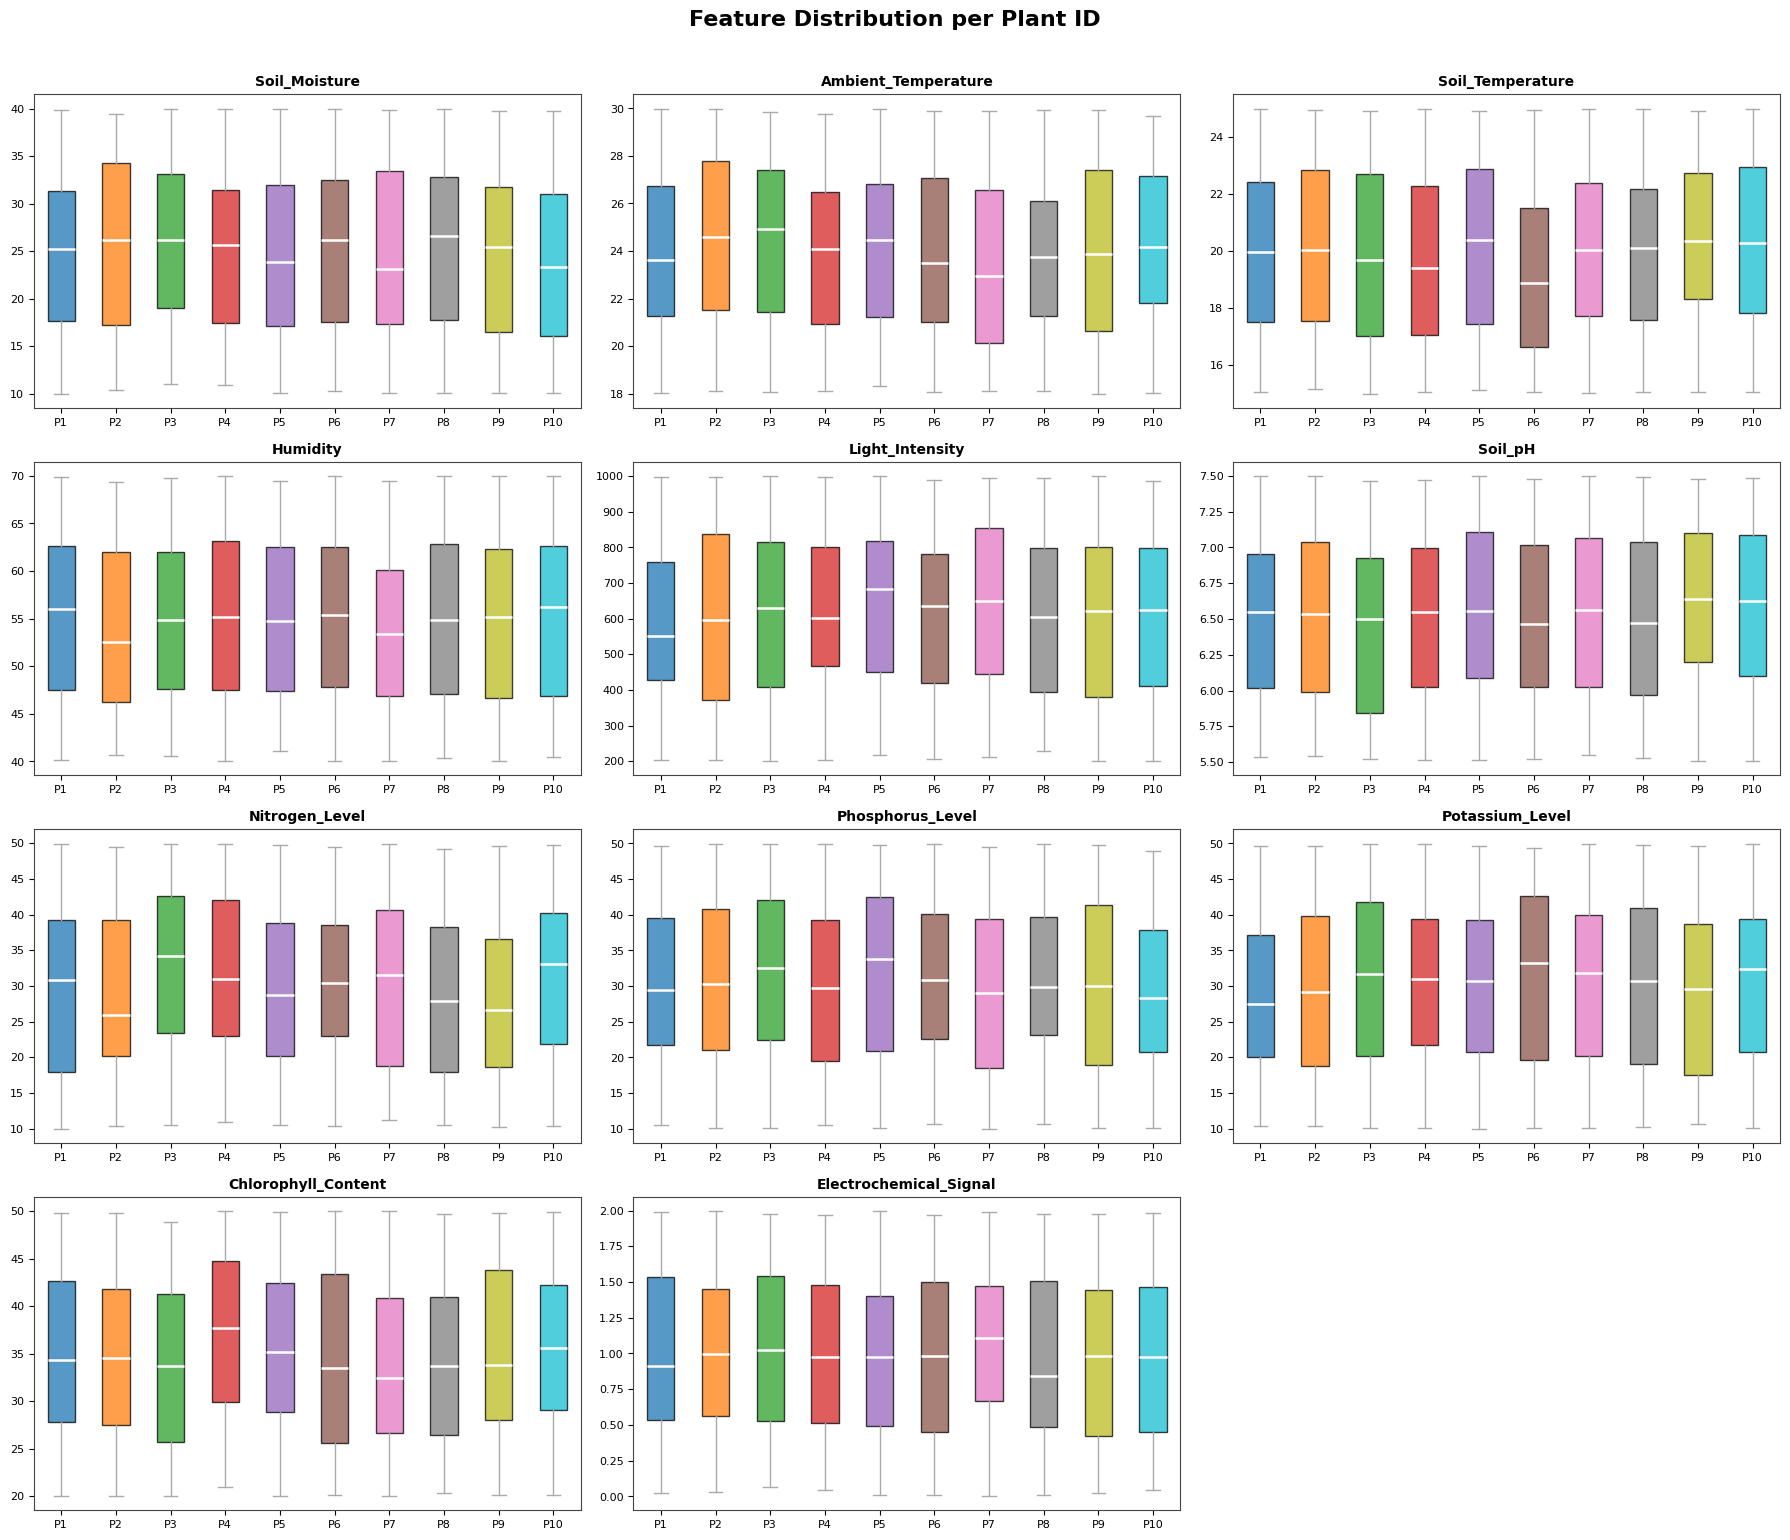

In [9]:
ncols = 3
nrows = -(-len(FEATURES) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.8))
fig.suptitle('Feature Distribution per Plant ID', fontsize=16,
             color=TEXT_COLOR, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, FEATURES):
    ax.set_facecolor(PANEL_BG)
    data = [df[df['Plant_ID'] == pid][feat].values for pid in PLANT_IDS]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 1.8},
                    whiskerprops={'color': '#aaa'}, capprops={'color': '#aaa'},
                    flierprops={'marker': 'o', 'markersize': 2,
                                'markerfacecolor': '#aaa', 'alpha': 0.5})
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(feat, fontsize=10, color=TEXT_COLOR, fontweight='bold', pad=6)
    ax.set_xticks(range(1, N_PLANTS + 1))
    ax.set_xticklabels([f'P{p}' for p in PLANT_IDS], fontsize=8, color=TEXT_COLOR)
    ax.tick_params(axis='y', colors=TEXT_COLOR, labelsize=8)
    ax.spines[['top','right','left','bottom']].set_color(GRID_COLOR)
    ax.grid(axis='y', linestyle='--', alpha=0.2, color='white')

for ax in axes.flat[len(FEATURES):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### 3.2 Heatmap — Mean Feature Values per Plant ID

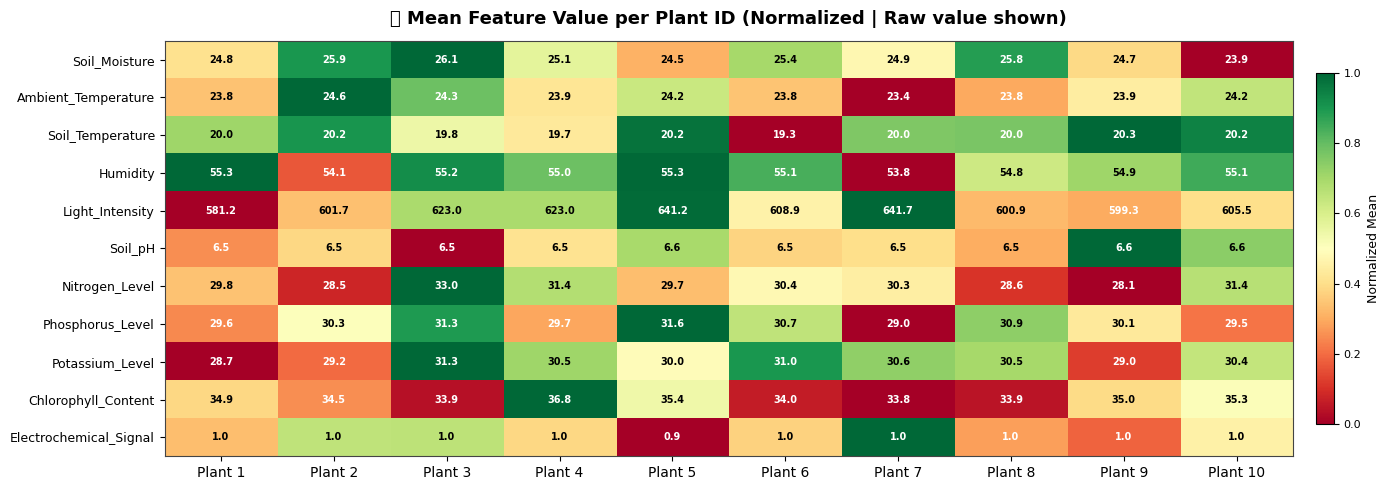

In [10]:
mean_df = df.groupby('Plant_ID')[FEATURES].mean()
norm_df = (mean_df - mean_df.min()) / (mean_df.max() - mean_df.min())

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor(DARK_BG)

im = ax.imshow(norm_df.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(N_PLANTS))
ax.set_xticklabels([f'Plant {p}' for p in PLANT_IDS], color=TEXT_COLOR, fontsize=10)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(FEATURES, color=TEXT_COLOR, fontsize=9)
ax.tick_params(colors=TEXT_COLOR)
ax.spines[['top','right','left','bottom']].set_color(GRID_COLOR)

for i, feat in enumerate(FEATURES):
    for j, pid in enumerate(PLANT_IDS):
        raw = mean_df.loc[pid, feat]
        nrm = norm_df.loc[pid, feat]
        tc  = 'black' if 0.3 < nrm < 0.75 else 'white'
        ax.text(j, i, f'{raw:.1f}', ha='center', va='center', fontsize=7,
                color=tc, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelsize=8)
cbar.set_label('Normalized Mean', color=TEXT_COLOR, fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_COLOR)
ax.set_title('🌡️ Mean Feature Value per Plant ID (Normalized | Raw value shown)',
             fontsize=13, color=TEXT_COLOR, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 3.3 Line Plot — Mean ± Std of Key Features

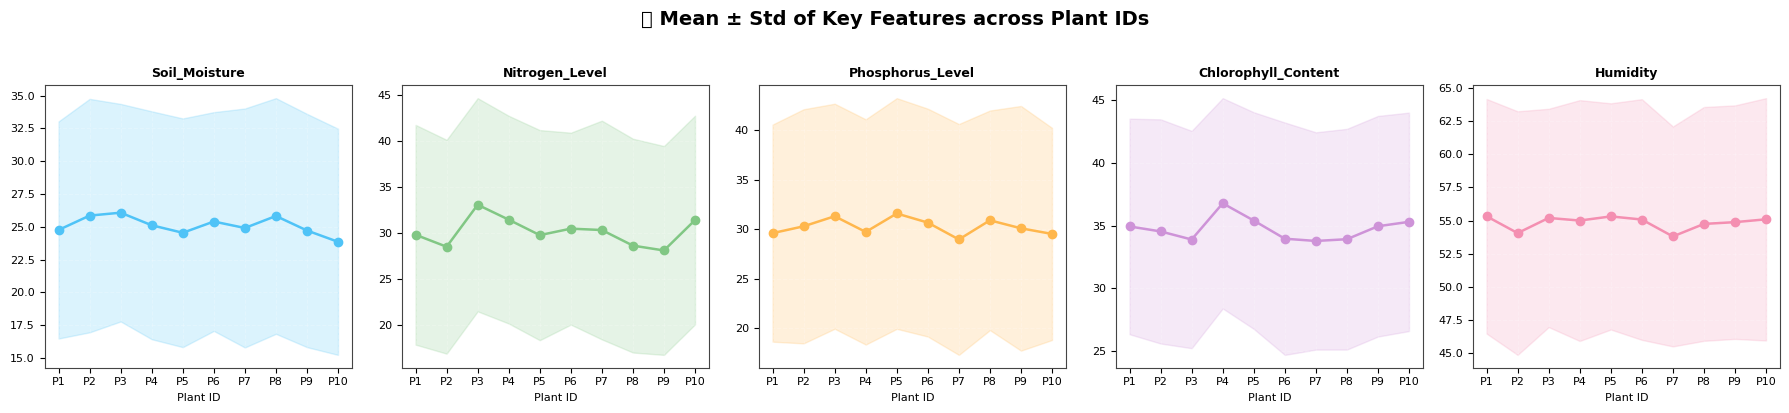

In [11]:
TOP_FEATS    = ['Soil_Moisture','Nitrogen_Level','Phosphorus_Level',
                'Chlorophyll_Content','Humidity']
LINE_COLORS  = ['#4FC3F7','#81C784','#FFB74D','#CE93D8','#F48FB1']

fig, axes = plt.subplots(1, len(TOP_FEATS), figsize=(18, 4))
fig.suptitle('📉 Mean ± Std of Key Features across Plant IDs',
             fontsize=14, color=TEXT_COLOR, fontweight='bold', y=1.02)

for ax, feat, color in zip(axes, TOP_FEATS, LINE_COLORS):
    ax.set_facecolor(PANEL_BG)
    means = df.groupby('Plant_ID')[feat].mean()
    stds  = df.groupby('Plant_ID')[feat].std()
    ax.plot(PLANT_IDS, means, marker='o', color=color,
            linewidth=1.8, markersize=6, zorder=3)
    ax.fill_between(PLANT_IDS, means - stds, means + stds, alpha=0.2, color=color)
    ax.set_title(feat, fontsize=9, color=TEXT_COLOR, fontweight='bold', pad=6)
    ax.set_xticks(PLANT_IDS)
    ax.set_xticklabels([f'P{p}' for p in PLANT_IDS], fontsize=8, color=TEXT_COLOR)
    ax.tick_params(axis='y', colors=TEXT_COLOR, labelsize=8)
    ax.spines[['top','right','left','bottom']].set_color(GRID_COLOR)
    ax.grid(linestyle='--', alpha=0.2, color='white')
    ax.set_xlabel('Plant ID', color=TEXT_COLOR, fontsize=8)

plt.tight_layout()
plt.show()


### 3.4 Health Status Distribution per Plant ID

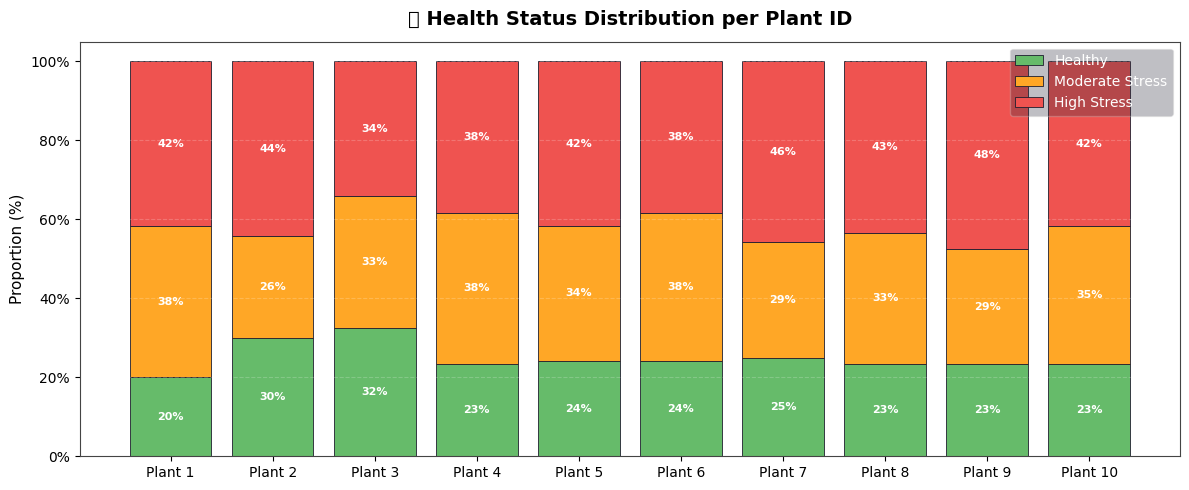

In [12]:
status_order  = ['Healthy', 'Moderate Stress', 'High Stress']
health_colors = {'Healthy': '#66BB6A', 'Moderate Stress': '#FFA726', 'High Stress': '#EF5350'}

status_cnts = (df.groupby(['Plant_ID','Plant_Health_Status'])
                 .size().unstack(fill_value=0)[status_order])
status_pct  = status_cnts.div(status_cnts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor(PANEL_BG)
bottom = np.zeros(N_PLANTS)

for status in status_order:
    vals = status_pct[status].values
    bars = ax.bar(PLANT_IDS, vals, bottom=bottom,
                  color=health_colors[status], label=status,
                  edgecolor='#1e1e2e', linewidth=0.6)
    for bar, val in zip(bars, vals):
        if val > 6:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xticks(PLANT_IDS)
ax.set_xticklabels([f'Plant {p}' for p in PLANT_IDS], color=TEXT_COLOR, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.tick_params(colors=TEXT_COLOR)
ax.spines[['top','right','left','bottom']].set_color(GRID_COLOR)
ax.set_ylim(0, 105)
ax.set_ylabel('Proportion (%)', color=TEXT_COLOR, fontsize=11)
ax.set_title('🌱 Health Status Distribution per Plant ID',
             fontsize=14, color=TEXT_COLOR, fontweight='bold', pad=12)
ax.legend(framealpha=0.3, labelcolor='white', facecolor='#2e2e3e', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.2, color='white')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

### 4.1 Label Encoding

In [13]:
# Custom ordinal mapping
custom_mapping = {'High Stress': 2, 'Moderate Stress': 1, 'Healthy': 0}
df['Plant_Health_Status_Encoded'] = df['Plant_Health_Status'].map(custom_mapping)

unique_value_counts = df['Plant_Health_Status_Encoded'].value_counts()
print(unique_value_counts)


Plant_Health_Status_Encoded
2    500
1    401
0    299
Name: count, dtype: int64


### 4.2 Drop Irrelevant Columns

In [14]:
# Drop Timestamp และ text label 
df = df.drop(['Timestamp', 'Plant_Health_Status','Plant_Name'], axis=1)
print("Columns after drop:", df.columns.tolist())
df.head()


Columns after drop: ['Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status_Encoded']


,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status_Encoded
0,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,2
1,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,2
2,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,2
3,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,2
4,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,2


### 4.3 Outlier Detection (Z-Score)

In [15]:
numerical_features = df.select_dtypes(include=[np.number]).columns

z_scores = zscore(df[numerical_features])
outliers_zscore = (np.abs(z_scores) > 3).sum(axis=0)
print("Outliers Detected with Z-scores:")
display(pd.DataFrame({'Column': numerical_features,
                      'Outlier Count': outliers_zscore}))


Outliers Detected with Z-scores:


,Column,Outlier Count
0,Plant_ID,0
1,Soil_Moisture,0
2,Ambient_Temperature,0
3,Soil_Temperature,0
4,Humidity,0
5,Light_Intensity,0
6,Soil_pH,0
7,Nitrogen_Level,0
8,Phosphorus_Level,0
9,Potassium_Level,0


### 4.4 Correlation Analysis

In [16]:
correlations = df.corr()['Plant_Health_Status_Encoded'].sort_values(ascending=False)
correlation_table = correlations.to_frame(
    name='Correlation with Plant_Health_Status_Encoded').reset_index()
correlation_table.rename(columns={'index': 'Feature'}, inplace=True)

display(correlation_table.style
        .bar(subset=['Correlation with Plant_Health_Status_Encoded'],
             align='mid', color=['#EF5350', '#66BB6A'])
        .format({'Correlation with Plant_Health_Status_Encoded': '{:.4f}'}))


,Feature,Correlation with Plant_Health_Status_Encoded
0,Plant_Health_Status_Encoded,1.0000
1,Soil_pH,0.0396
2,Plant_ID,0.0318
3,Light_Intensity,0.0263
4,Electrochemical_Signal,0.0210
5,Ambient_Temperature,-0.0007
6,Chlorophyll_Content,-0.0072
7,Soil_Temperature,-0.0089
8,Potassium_Level,-0.0229
9,Humidity,-0.0450


### 4.5 Feature Scaling & Train/Test Split

In [17]:
X = df.drop(columns=['Plant_Health_Status_Encoded'])
y = df['Plant_Health_Status_Encoded']
FEATURE_NAMES = list(X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features : {FEATURE_NAMES}")
print(f"X_train  : {X_train.shape}")
print(f"X_test   : {X_test.shape}")
print(f"y_train  : {y_train.shape}")
print(f"y_test   : {y_test.shape}")


Features : ['Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']
X_train  : (960, 12)
X_test   : (240, 12)
y_train  : (960,)
y_test   : (240,)


## 5. Feature Selection — Mutual Information

📊 Mutual Information Scores (incl. Plant_ID):


,Feature,MI Score
0,Soil_Moisture,0.7256
1,Nitrogen_Level,0.1564
2,Soil_pH,0.0204
3,Ambient_Temperature,0.0161
4,Humidity,0.0029
5,Light_Intensity,0.0009
6,Soil_Temperature,0.0000
7,Plant_ID,0.0000
8,Phosphorus_Level,0.0000
9,Potassium_Level,0.0000


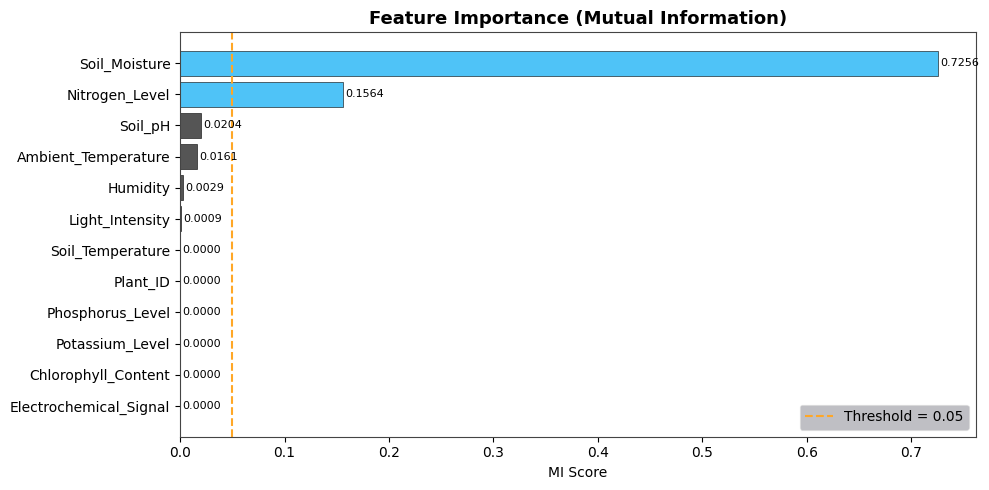

In [18]:
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature':  FEATURE_NAMES,
    'MI Score': selector.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print("📊 Mutual Information Scores (incl. Plant_ID):")
display(feature_scores.style
        .bar(subset=['MI Score'], color='#4C72B0')
        .format({'MI Score': '{:.4f}'})
        .set_caption('Feature Importance — Mutual Information'))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor(PANEL_BG)
colors_bar = ['#4FC3F7' if s > 0.05 else '#555' for s in feature_scores['MI Score']]
bars = ax.barh(feature_scores['Feature'], feature_scores['MI Score'],
               color=colors_bar, edgecolor='black', linewidth=0.4)
ax.axvline(0.05, color='#FFA726', linestyle='--', linewidth=1.5, label='Threshold = 0.05')
for bar, val in zip(bars, feature_scores['MI Score']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8, color='black')
ax.set_xlabel('MI Score', color=TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)
ax.spines[['top','right','left','bottom']].set_color(GRID_COLOR)
ax.invert_yaxis()
ax.legend(framealpha=0.3, labelcolor='black', facecolor='#2e2e3e')
ax.set_title('Feature Importance (Mutual Information)', fontsize=13,
             color=TEXT_COLOR, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_mi.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [19]:
THRESHOLD = 0.05
selected_features = feature_scores[feature_scores['MI Score'] > THRESHOLD]['Feature'].tolist()
selected_idx = [FEATURE_NAMES.index(f) for f in selected_features]

X_train_fs = X_train[:, selected_idx]
X_test_fs  = X_test[:, selected_idx]

plant_id_in = 'Plant_ID' in selected_features
print(f"✅ Selected {len(selected_features)} features [MI > {THRESHOLD}]:")
for f in selected_features:
    score = feature_scores.loc[feature_scores['Feature']==f, 'MI Score'].values[0]
    print(f"   • {f:30s}  MI={score:.4f}")
print(f"\nPlant_ID ผ่าน threshold? → {'✅ YES — ยังอยู่ใน selected set' if plant_id_in else '❌ NO — ถูกตัดออกโดย selection'}")
print(f"Feature count: {X_train.shape[1]} → {X_train_fs.shape[1]}")


✅ Selected 2 features [MI > 0.05]:
   • Soil_Moisture                   MI=0.7256
   • Nitrogen_Level                  MI=0.1564

Plant_ID ผ่าน threshold? → ❌ NO — ถูกตัดออกโดย selection
Feature count: 12 → 2


## 6. SMOTE — Handle Class Imbalance

,Before SMOTE,After SMOTE,Δ Added
Plant_Health_Status_Encoded,,,
High Stress,400,400,0
Moderate Stress,321,400,79
Healthy,239,400,161



Total samples: 960 → 1200 (+240)


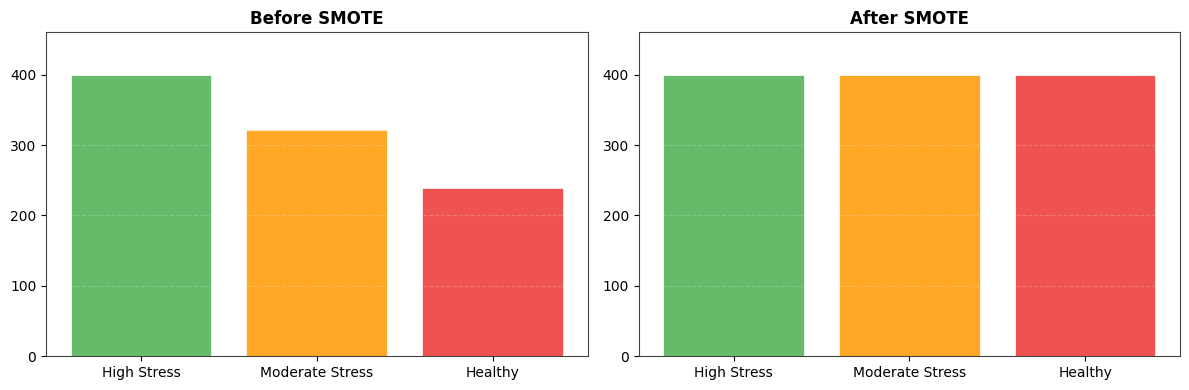

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_fs, y_train)

label_map = {0: 'Healthy', 1: 'Moderate Stress', 2: 'High Stress'}
before = y_train.value_counts().rename(label_map)
after  = pd.Series(y_train_sm).value_counts().rename(label_map)

smote_compare = pd.DataFrame({'Before SMOTE': before, 'After SMOTE': after})
smote_compare['Δ Added'] = smote_compare['After SMOTE'] - smote_compare['Before SMOTE']
display(smote_compare)
print(f"\nTotal samples: {len(y_train)} → {len(y_train_sm)} (+{len(y_train_sm)-len(y_train)})")

# Bar comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

STATUS_COLORS = ['#66BB6A', '#FFA726', '#EF5350']
for ax, (title, data) in zip(axes, [('Before SMOTE', before), ('After SMOTE', after)]):

    bars = ax.bar(data.index, data.values, color=STATUS_COLORS,
                  edgecolor='white', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(int(bar.get_height())), ha='center', fontsize=11,
                color='white', fontweight='bold')
    ax.set_title(title, color=TEXT_COLOR, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT_COLOR); ax.set_ylim(0, max(after.values) * 1.15)
    ax.spines[['top','right','left','bottom']].set_color(GRID_COLOR)
    ax.grid(axis='y', linestyle='--', alpha=0.2, color='white')
plt.tight_layout()
plt.show()


## 7. Model Training — 3 Experiments

In [21]:
CLASS_NAMES = ['Healthy', 'Moderate Stress', 'High Stress']

def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
        'SVM':                 SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
        'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                           max_depth=5, random_state=42),
        'LightGBM':            lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1,
                                                   max_depth=5, random_state=42, verbose=-1),
        'CatBoost':            CatBoostClassifier(iterations=200, learning_rate=0.1,
                                                  depth=5, random_state=42, verbose=0),
    }

def run_experiment(X_tr, y_tr, X_te, y_te, exp_name):
    print(f"\n{'━'*60}")
    print(f"{exp_name}")
    print(f"{'━'*60}")
    models = get_models()
    rows   = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        rows.append({
            'Model':      name,
            'Accuracy':   round(accuracy_score(y_te, y_pred), 4),
            'Precision':  round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
            'Recall':     round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
            'F1-Score':   round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
            '_y_pred':    y_pred,
            '_model_obj': model,  
        })
        print(f"  [{name:22s}]  Acc={rows[-1]['Accuracy']:.4f}  F1={rows[-1]['F1-Score']:.4f}")
    df_res = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)
    df_res.index += 1
    return df_res 

DISP_COLS = ['Model','Accuracy','Precision','Recall','F1-Score']

def show_table(df_res, caption):
    display(df_res[DISP_COLS].style
            .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1-Score']})
            .set_caption(caption))



### 7.1 EXP 1 — Baseline (All Features incl. Plant_ID, No SMOTE)

In [33]:
df_exp1 = run_experiment(X_train, y_train, X_test, y_test,
                         f'EXP 1 — Baseline ({X_train.shape[1]} features, No SMOTE)')
show_table(df_exp1, 'EXP 1 — Baseline (All Features)')



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXP 1 — Baseline (12 features, No SMOTE)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Logistic Regression   ]  Acc=0.7583  F1=0.7567
  [K-Nearest Neighbors   ]  Acc=0.6333  F1=0.6405
  [Decision Tree         ]  Acc=0.9917  F1=0.9917
  [Random Forest         ]  Acc=0.9875  F1=0.9875
  [SVM                   ]  Acc=0.8042  F1=0.8054
  [Gradient Boosting     ]  Acc=0.9917  F1=0.9917
  [LightGBM              ]  Acc=0.9875  F1=0.9875
  [CatBoost              ]  Acc=0.9875  F1=0.9875


,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.9917,0.9919,0.9917,0.9917
2,Gradient Boosting,0.9917,0.9919,0.9917,0.9917
3,LightGBM,0.9875,0.9876,0.9875,0.9875
4,Random Forest,0.9875,0.9876,0.9875,0.9875
5,CatBoost,0.9875,0.9875,0.9875,0.9875
6,SVM,0.8042,0.8081,0.8042,0.8054
7,Logistic Regression,0.7583,0.7558,0.7583,0.7567
8,K-Nearest Neighbors,0.6333,0.6554,0.6333,0.6405


### 7.2 EXP 2 — Feature Selection (No SMOTE)

In [23]:
df_exp2 = run_experiment(X_train_fs, y_train, X_test_fs, y_test,
                         f'EXP 2 — Feature Selection ({X_train_fs.shape[1]} features, No SMOTE)')
show_table(df_exp2, f'EXP 2 — Feature Selection: {selected_features}')



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXP 2 — Feature Selection (2 features, No SMOTE)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Logistic Regression   ]  Acc=0.7458  F1=0.7459
  [K-Nearest Neighbors   ]  Acc=0.9458  F1=0.9462
  [Decision Tree         ]  Acc=0.9917  F1=0.9917
  [Random Forest         ]  Acc=0.9875  F1=0.9875
  [SVM                   ]  Acc=0.9333  F1=0.9338
  [Gradient Boosting     ]  Acc=0.9917  F1=0.9917
  [LightGBM              ]  Acc=0.9875  F1=0.9875
  [CatBoost              ]  Acc=0.9917  F1=0.9917


,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.9917,0.9919,0.9917,0.9917
2,Gradient Boosting,0.9917,0.9919,0.9917,0.9917
3,CatBoost,0.9917,0.9917,0.9917,0.9917
4,Random Forest,0.9875,0.9876,0.9875,0.9875
5,LightGBM,0.9875,0.9876,0.9875,0.9875
6,K-Nearest Neighbors,0.9458,0.9474,0.9458,0.9462
7,SVM,0.9333,0.9360,0.9333,0.9338
8,Logistic Regression,0.7458,0.7470,0.7458,0.7459


### 7.3 EXP 3 — Feature Selection + SMOTE

In [24]:
df_exp3 = run_experiment(X_train_sm, y_train_sm, X_test_fs, y_test,
                         f'EXP 3 — Feature Selection + SMOTE ({X_train_fs.shape[1]} features)')
show_table(df_exp3, 'EXP 3 — Feature Selection + SMOTE')



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXP 3 — Feature Selection + SMOTE (2 features)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Logistic Regression   ]  Acc=0.7417  F1=0.7433
  [K-Nearest Neighbors   ]  Acc=0.9500  F1=0.9503
  [Decision Tree         ]  Acc=0.9917  F1=0.9917
  [Random Forest         ]  Acc=0.9875  F1=0.9875
  [SVM                   ]  Acc=0.9375  F1=0.9376
  [Gradient Boosting     ]  Acc=0.9875  F1=0.9875
  [LightGBM              ]  Acc=0.9750  F1=0.9751
  [CatBoost              ]  Acc=0.9917  F1=0.9917


,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.9917,0.9919,0.9917,0.9917
2,CatBoost,0.9917,0.9919,0.9917,0.9917
3,Gradient Boosting,0.9875,0.9876,0.9875,0.9875
4,Random Forest,0.9875,0.9876,0.9875,0.9875
5,LightGBM,0.9750,0.9759,0.9750,0.9751
6,K-Nearest Neighbors,0.9500,0.9512,0.9500,0.9503
7,SVM,0.9375,0.9377,0.9375,0.9376
8,Logistic Regression,0.7417,0.7458,0.7417,0.7433


In [34]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

# ── Save best model จากแต่ละ experiment ──────────────────────
EXP_MAP = {
    'exp1_baseline': df_exp1,
    'exp2_feat_sel': df_exp2,
    'exp3_fs_smote': df_exp3,
}

for exp_name, df_e in EXP_MAP.items():
    best       = df_e.iloc[0]
    model_name = best['Model'].replace(' ', '_').lower()
    model_obj  = best['_model_obj']
    path       = f'saved_models/{exp_name}_{model_name}.pkl'

    joblib.dump(model_obj, path)
    print(f'Saved: {path}')

# ── Save scaler ด้วย (สำคัญมาก!) ─────────────────────────────
joblib.dump(scaler, 'saved_models/scaler.pkl')
print('Saved: saved_models/scaler.pkl')

print('\n✅ Done! Files in saved_models/:')
for f in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{f}') / 1024
    print(f'   {f:50s}  {size:.1f} KB')


Saved: saved_models/exp1_baseline_decision_tree.pkl
Saved: saved_models/exp2_feat_sel_decision_tree.pkl
Saved: saved_models/exp3_fs_smote_decision_tree.pkl
Saved: saved_models/scaler.pkl

✅ Done! Files in saved_models/:
   best_model_exp2_feat_sel_decision_tree.pkl          2.2 KB
   exp1_baseline_decision_tree.pkl                     2.2 KB
   exp2_feat_sel_decision_tree.pkl                     2.2 KB
   exp3_fs_smote_decision_tree.pkl                     2.2 KB
   scaler.pkl                                          1.3 KB


## 8. Results Comparison

### 8.1 Cross-Experiment F1-Score Table

In [28]:
EXP_MAP = {
    'EXP1 (Baseline)':   df_exp1,
    'EXP2 (Feat.Sel.)':  df_exp2,
    'EXP3 (FS+SMOTE)':   df_exp3,
}

model_order = df_exp1['Model'].tolist()
comparison  = pd.DataFrame({'Model': model_order})
for label, df_e in EXP_MAP.items():
    tmp = df_e[['Model','F1-Score']].rename(columns={'F1-Score': label})
    comparison = comparison.merge(tmp, on='Model', how='left')

comparison = comparison.set_index('Model')
comparison['Δ (EXP3−EXP1)'] = (comparison['EXP3 (FS+SMOTE)'] - comparison['EXP1 (Baseline)']).round(4)

display(comparison.style
        .map(lambda v: 'color:#66BB6A;font-weight:bold' if isinstance(v, float) and v > 0
                  else ('color:#EF5350;font-weight:bold' if isinstance(v, float) and v < 0 else ''),
                  subset=['Δ (EXP3−EXP1)'])
        .format({k: '{:.4f}' for k in list(EXP_MAP.keys()) + ['Δ (EXP3−EXP1)']})
        .set_caption('F1-Score (weighted) | Δ = EXP3 − EXP1'))


,EXP1 (Baseline),EXP2 (Feat.Sel.),EXP3 (FS+SMOTE),Δ (EXP3−EXP1)
Model,,,,
Decision Tree,0.9917,0.9917,0.9917,0.0000
Gradient Boosting,0.9917,0.9917,0.9875,-0.0042
LightGBM,0.9875,0.9875,0.9751,-0.0124
Random Forest,0.9875,0.9875,0.9875,0.0000
CatBoost,0.9875,0.9917,0.9917,0.0042
SVM,0.8054,0.9338,0.9376,0.1322
Logistic Regression,0.7567,0.7459,0.7433,-0.0134
K-Nearest Neighbors,0.6405,0.9462,0.9503,0.3098


### 8.2 Bar Chart — F1-Score per Model × Experiment

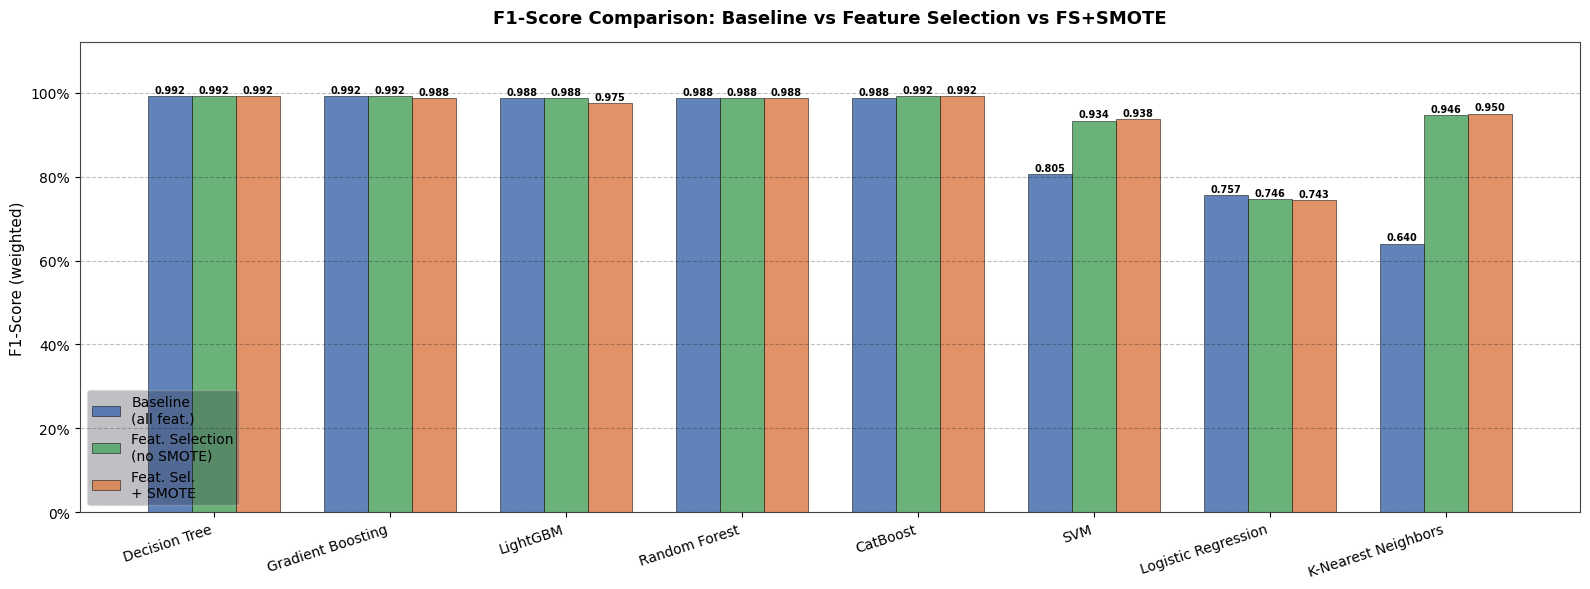

In [32]:
exp_cols   = list(EXP_MAP.keys())
exp_labels = ['Baseline\n(all feat.)', 'Feat. Selection\n(no SMOTE)', 'Feat. Sel.\n+ SMOTE']
palette    = ['#4C72B0', '#55A868', '#DD8452']
x          = np.arange(len(model_order))
bar_width  = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

for i, (col, label, color) in enumerate(zip(exp_cols, exp_labels, palette)):
    vals = comparison[col].values
    bars = ax.bar(x + i * bar_width, vals, bar_width, label=label,
                  color=color, alpha=0.88, edgecolor='black', linewidth=0.4)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7, color='black', fontweight='bold')

ax.set_xticks(x + bar_width)
ax.set_xticklabels(model_order, rotation=18, ha='right', fontsize=10, color='black')
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(colors='black')
ax.spines[['top','right','left','bottom']].set_color('#444')
ax.legend(framealpha=0.3, labelcolor='black', facecolor='#2e2e3e', fontsize=10)
ax.set_title('F1-Score Comparison: Baseline vs Feature Selection vs FS+SMOTE',
             fontsize=13, color='black', fontweight='bold', pad=14)
ax.set_ylabel('F1-Score (weighted)', color='black', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.25, color='black')
plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


### 8.3 Confusion Matrices — Best Model per Experiment

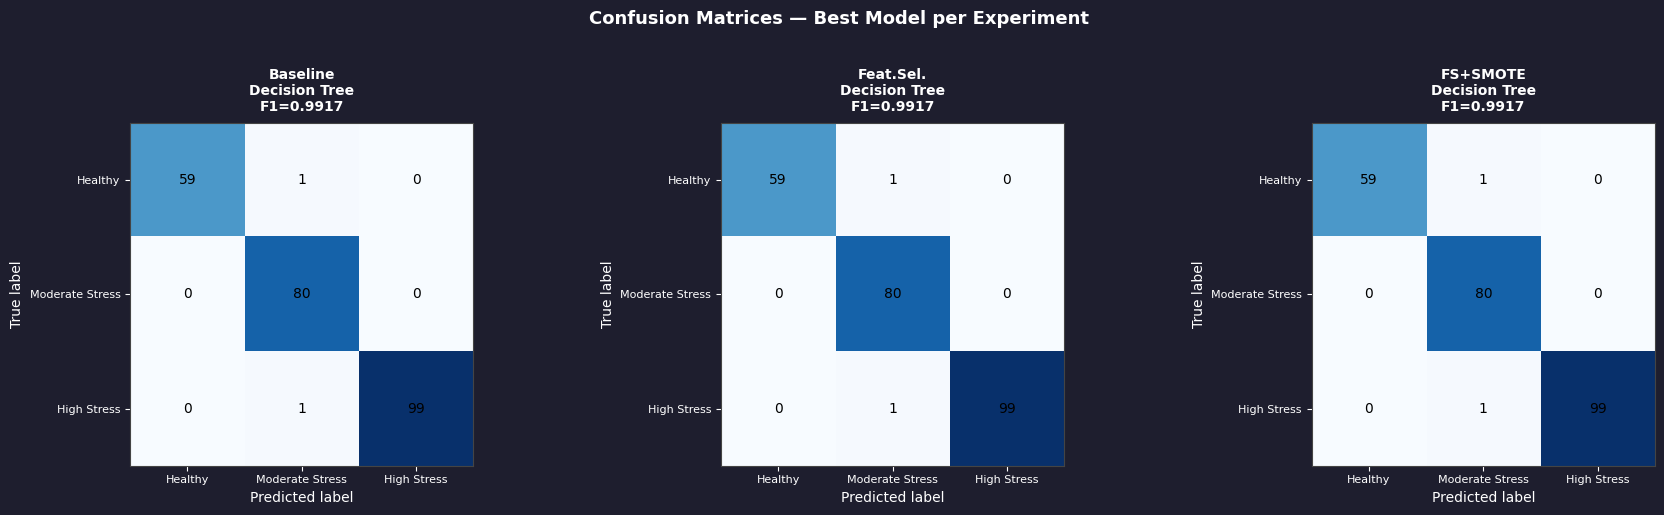


🏆 Best Overall:
   Experiment : Baseline
   Model      : Decision Tree
   F1-Score   : 0.9917


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Confusion Matrices — Best Model per Experiment',
             fontsize=13, color='white', fontweight='bold', y=1.02)

overall_best = {'f1': -1, 'model': '', 'exp': ''}

for ax, (exp_label, df_e), short in zip(
        axes, EXP_MAP.items(), ['Baseline','Feat.Sel.','FS+SMOTE']):
    best = df_e.iloc[0]
    cm   = confusion_matrix(y_test, best['_y_pred'])
    ax.set_facecolor(DARK_BG)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    if best['F1-Score'] > overall_best['f1']:
        overall_best = {'f1': best['F1-Score'], 'model': best['Model'], 'exp': short}
    ax.set_title(f'{short}\n{best["Model"]}\nF1={best["F1-Score"]:.4f}',
                 fontsize=10, color='white', fontweight='bold', pad=8)
    ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
    ax.tick_params(colors='white', labelsize=8)
    for text in disp.text_.ravel(): text.set_color('black')
    ax.spines[['top','right','left','bottom']].set_color('#444')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print(f'\n🏆 Best Overall:')
print(f'   Experiment : {overall_best["exp"]}')
print(f'   Model      : {overall_best["model"]}')
print(f'   F1-Score   : {overall_best["f1"]:.4f}')


### 8.4 Best Model — Detailed Classification Report

In [ ]:
# หา experiment และ model ที่ดีที่สุด
best_exp_df = max(EXP_MAP.values(), key=lambda d: d.iloc[0]['F1-Score'])
best_row    = best_exp_df.iloc[0]

print(f"🏆 Best Model: {best_row['Model']}")
print(f"\n{classification_report(y_test, best_row['_y_pred'], target_names=CLASS_NAMES)}")


🏆 Best Model: Decision Tree

                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      1.00      0.99        80
    High Stress       1.00      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



In [4]:
import joblib

model = joblib.load("saved_models/best_model_exp2_feat_sel_decision_tree.pkl")

In [5]:
tree = model.tree_
feature_names = ["Soil_Moisture", "Nitrogen_Level"]

for i in range(tree.node_count):
    if tree.feature[i] != -2:
        name = feature_names[tree.feature[i]]
        threshold = tree.threshold[i]
        print(f"{name} <= {threshold:.2f}")

Soil_Moisture <= -0.59
Soil_Moisture <= 0.57
Nitrogen_Level <= -1.31
Nitrogen_Level <= -0.88
Nitrogen_Level <= -1.32


In [6]:
from sklearn.tree import export_text

rules = export_text(model, feature_names=["Soil_Moisture", "Nitrogen_Level"])
print(rules)

|--- Soil_Moisture <= -0.59
|   |--- class: 2
|--- Soil_Moisture >  -0.59
|   |--- Soil_Moisture <= 0.57
|   |   |--- Nitrogen_Level <= -1.31
|   |   |   |--- class: 2
|   |   |--- Nitrogen_Level >  -1.31
|   |   |   |--- class: 1
|   |--- Soil_Moisture >  0.57
|   |   |--- Nitrogen_Level <= -0.88
|   |   |   |--- Nitrogen_Level <= -1.32
|   |   |   |   |--- class: 2
|   |   |   |--- Nitrogen_Level >  -1.32
|   |   |   |   |--- class: 1
|   |   |--- Nitrogen_Level >  -0.88
|   |   |   |--- class: 0



In [8]:
import joblib

scaler = joblib.load("saved_models/scaler.pkl")

In [9]:
mean = scaler.mean_
std = scaler.scale_

print(mean)
print(std)

[  5.5         25.10691805  23.99912999  19.9577943   54.85316511
 612.63726538   6.52410205  30.10675088  30.26448401  30.11208846
  34.74959091   0.98776368]
[  2.87228132   8.67410851   3.44012685   2.93085089   8.78125467
 228.22370021   0.58151297  11.50959722  11.46206733  11.66322201
   8.76334132   0.57487601]


In [ ]:
import numpy as np
import joblib

# =========================
# LOAD MODEL + SCALER
# =========================
model  = joblib.load("saved_models/best_model_exp2_feat_sel_decision_tree.pkl")
scaler = joblib.load("saved_models/scaler.pkl")

# =========================
# CONFIG
# =========================
ALL_FEATURE_NAMES = [
    'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature',
    'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level',
    'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content',
    'Electrochemical_Signal',
]

SELECTED_FEATURES = ['Soil_Moisture', 'Nitrogen_Level']
SELECTED_INDICES  = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

label_map = {
    0: "Healthy",
    1: "Moderate Stress",
    2: "High Stress"
}

# =========================
# PREDICT FUNCTION
# =========================
def predict_one(soil_val, nitrogen_val):
    full_input = np.zeros((1, len(ALL_FEATURE_NAMES)))
    full_input[0, ALL_FEATURE_NAMES.index('Soil_Moisture')]  = soil_val
    full_input[0, ALL_FEATURE_NAMES.index('Nitrogen_Level')] = nitrogen_val
    
    scaled_full = scaler.transform(full_input)
    scaled_selected = scaled_full[:, SELECTED_INDICES]
    
    pred = int(model.predict(scaled_selected)[0])
    return label_map[pred]

# =========================
# 🔥 YOUR NEW THRESHOLDS
# =========================

def soil_level(x):
    if x <= 20:
        return "Dry"
    elif x <= 30:
        return "Moist"
    else:
        return "Wet"

def nitrogen_level(x):
    if x <= 19.5:
        return "Yellow"
    elif x <= 21:
        return "Green"
    else:
        return "Dark Green"

# =========================
# REPRESENTATIVE VALUES
# =========================

soil_rep = {
    "Dry": 15,      
    "Moist": 25,
    "Wet": 35
}

nitrogen_rep = {
    "Yellow": 18,   
    "Green": 20.5,
    "Dark Green": 30
}

# =========================
# 🔥 TEST GRID (3x3)
# =========================
print("\n=== TEST 3x3 GRID ===")

for s_label, s_val in soil_rep.items():
    for n_label, n_val in nitrogen_rep.items():
        pred = predict_one(s_val, n_val)
        print(f"{s_label:>6} x {n_label:>10}  ->  {pred}")




=== TEST 3x3 GRID ===
   Dry x     Yellow  ->  High Stress
   Dry x      Green  ->  High Stress
   Dry x Dark Green  ->  High Stress
 Moist x     Yellow  ->  Moderate Stress
 Moist x      Green  ->  Moderate Stress
 Moist x Dark Green  ->  Moderate Stress
   Wet x     Yellow  ->  Moderate Stress
   Wet x      Green  ->  Healthy
   Wet x Dark Green  ->  Healthy


In [ ]:
from sklearn.model_selection import train_test_split
custom_mapping = {
    'High Stress': 2,
    'Moderate Stress': 1,
    'Healthy': 0
}

df['label'] = df['Plant_Health_Status'].map(custom_mapping)
# เตรียม data
df_work = df.copy()
df_work = df_work.drop(['Timestamp', 'Plant_Health_Status', 'Plant_Name'], axis=1)

X = df_work.drop(columns=['label'])
y = df_work['label']

# scale
X_scaled = scaler.transform(X)

# split
_, X_test, _, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# inverse กลับมาเป็นค่าจริง
X_test_unscaled = scaler.inverse_transform(X_test)

# index ของ feature
sm_idx = ALL_FEATURE_NAMES.index('Soil_Moisture')
nl_idx = ALL_FEATURE_NAMES.index('Nitrogen_Level')

In [ ]:
correct = 0
total = 0

for i in range(len(X_test)):
    raw_sm = X_test_unscaled[i, sm_idx]
    raw_nl = X_test_unscaled[i, nl_idx]

    s_level = soil_level(raw_sm)
    n_level = nitrogen_level(raw_nl)

    pred = predict_one(
        soil_rep[s_level],
        nitrogen_rep[n_level]
    )

    if pred == label_map[y_test.iloc[i]]:
        correct += 1
    total += 1

print("Accuracy (new rule):", correct / total)

Accuracy (new rule): 0.8833333333333333


In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# เก็บ prediction
y_pred = []

for i in range(len(X_test)):
    raw_sm = X_test_unscaled[i, sm_idx]
    raw_nl = X_test_unscaled[i, nl_idx]

    s_level = soil_level(raw_sm)
    n_level = nitrogen_level(raw_nl)

    pred = predict_one(
        soil_rep[s_level],
        nitrogen_rep[n_level]
    )

    # แปลงชื่อกลับเป็น id (สำคัญ)
    pred_id = {v: k for k, v in label_map.items()}[pred]

    y_pred.append(pred_id)

y_pred = np.array(y_pred)

# =========================
# 🔥 METRICS
# =========================

print("\n=== LEVEL-BASED RESULTS ===")

print("\nAccuracy:")
print(correct / total)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Healthy", "Moderate Stress", "High Stress"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== LEVEL-BASED RESULTS ===

Accuracy:
0.8833333333333333

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.98      1.00      0.99        60
Moderate Stress       0.75      0.99      0.85        80
    High Stress       1.00      0.73      0.84       100

       accuracy                           0.88       240
      macro avg       0.91      0.91      0.90       240
   weighted avg       0.91      0.88      0.88       240


Confusion Matrix:
[[60  0  0]
 [ 1 79  0]
 [ 0 27 73]]
